# Preprocess .mat files
* version 1.1 CS 10
* data 20.10.2025
* author A.Subbotin

In [2]:
import scipy.io as sio  # Ensure scipy is imported for .mat file handling
import numpy as np  # Ensure numpy is imported for array handling
import pandas as pd  # Ensure pandas is imported for DataFrame handling
import matplotlib.pyplot as plt  # Ensure matplotlib is imported for plotting

In [3]:
def mat_to_pandas(mat_file_path, features_list):
    data = sio.loadmat(mat_file_path)

    # Extract the relevant data from the loaded .mat file
    insData = data['insData']
    extracted_data = {feature: insData[feature][0][0][0][0]['value'].T[0]  for feature in features_list}
    extracted_data['time'] = insData[features_list[0]][0][0][0][0]['time'].T[0]  # Extracting time separately    
    # Convert the extracted data to a pandas DataFrame
    df = pd.DataFrame.from_dict(extracted_data)

    return df

# Example usage
example_file_path = r"C:\Users\msbka\PINNS\Dataset\20140221_04_01_03_250lm.mat"

features = ['latitude', 'longitude', 'sideSlip', 'vxCG', 'vyCG', 'axCG', 'ayCG', 'yawRate']

features_filt = ['latitude', 'longitude', 'sideSlip', 'vxCG', 'vyCG', 'axCGFilt', 'ayCGFilt', 'yawRateFilt']
df = mat_to_pandas(example_file_path, features)

# Display the first few rows of the DataFrame
print(df.head())

   latitude  longitude  sideSlip  vxCG  vyCG      axCG      ayCG   yawRate  \
0       NaN        NaN       0.0   0.0   0.0  0.054183  0.042289  0.037534   
1       NaN        NaN       0.0   0.0   0.0  0.147014 -0.058505  0.388898   
2       NaN        NaN       0.0   0.0   0.0 -0.291975  0.730036 -0.142416   
3       NaN        NaN       0.0   0.0   0.0  0.111661 -0.086679  0.120025   
4       NaN        NaN       0.0   0.0   0.0  0.001944  0.053631  0.184540   

   time  
0  0.00  
1  0.01  
2  0.02  
3  0.03  
4  0.04  


* vxCG                       longitudinal velocity of the vehicle body measured at the center of gravity in meters per second
* vyCG                       lateral velocity of the vehicle body measured at the center of gravity in meters per second

* axCG                       longitudinal acceleration of the vehicle body measured at the center of gravity in meters per second per second
* ayCG                       lateral acceleration of the vehicle body measured at the center of gravity in meters per second per second

* yawRate                    vehicle body-frame angular rate in the z-direction in degrees per second
* yawAngle                   yaw angle (heading) of the vehicle body in degrees

* sideSlip                   vehicle body side slip angle defined as the angle between the vehicle body heading and the vehicle body horizontal velocity vector in degrees

In [4]:
from datetime import timedelta

def save_to_file(data, file_name):
    """
    Save the DataFrame to a CSV file.
    
    Parameters:
    data (pd.DataFrame): The DataFrame to save.
    file_name (str): The name of the file to save the DataFrame to.
    """
    data.to_csv(file_name, index=False)
    print(f"Data saved to {file_name}")

def plot_data(dataset, start_t=1000, stop_t=2260):
    start_td = timedelta(seconds=int(start_t))
    stop_td = timedelta(seconds=int(stop_t))
    duration_td = timedelta(seconds=int(stop_t - start_t))

    print(f"Start time: {str(start_td)}")
    print(f"Stop time: {str(stop_td)}")
    print(f"Duration: {str(duration_td)}")
    
    
    plt.figure(figsize=(20, 6))
    plt.plot(dataset['time'], dataset['vxCG'], label='Velocity X', color='blue')
    plt.plot(dataset['time'], dataset['vyCG'], label='Velocity Y', color='red')
    plt.vlines([start_t, stop_t], ymin=min(dataset['vxCG'].min(), dataset['vyCG'].min()),
           ymax=max(dataset['vxCG'].max(), dataset['vyCG'].max()),
           colors='green', linestyles='dashed', label='Interval')
    plt.ion()
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (m/s)')
    plt.title('Vehicle Velocities Over Time')
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(20, 6))
    plt.plot(dataset['time'], dataset['sideSlip'], label='Side Slip', color='purple')
    plt.vlines([start_t, stop_t], ymin=dataset['sideSlip'].min(), ymax=dataset['sideSlip'].max(),
           colors='green', linestyles='dashed', label='Interval')
    plt.xlabel('Time (s)')
    plt.ylabel('Side Slip (grad)')
    plt.title('Vehicle Side Slip Over Time')
    plt.legend()
    plt.grid()
    plt.show()
    
def plot_vehicle_path(train_data):
    plt.figure(figsize=(10, 6))
    plt.scatter(train_data['latitude'], train_data['longitude'], c=train_data['sideSlip'].abs(), label='Vehicle Path', marker='.', s=1, edgecolors='none', cmap='coolwarm', alpha=0.5,
                norm=plt.Normalize(vmin=0, vmax=1))
    plt.colorbar(label='Side Slip')
    plt.xlabel('Latitude')
    plt.ylabel('Longitude')
    plt.title('Vehicle Path Colored by Side Slip')
    plt.legend()
    plt.grid()
    plt.show()

___
# Test  data

In [5]:

test_file_path = r"C:\Users\msbka\PINNS\Dataset\20140221_04_01_03_250lm.mat"
test_data = mat_to_pandas(test_file_path, features)
# Display the first few rows of the test DataFrame
print(test_data.head())

   latitude  longitude  sideSlip  vxCG  vyCG      axCG      ayCG   yawRate  \
0       NaN        NaN       0.0   0.0   0.0  0.054183  0.042289  0.037534   
1       NaN        NaN       0.0   0.0   0.0  0.147014 -0.058505  0.388898   
2       NaN        NaN       0.0   0.0   0.0 -0.291975  0.730036 -0.142416   
3       NaN        NaN       0.0   0.0   0.0  0.111661 -0.086679  0.120025   
4       NaN        NaN       0.0   0.0   0.0  0.001944  0.053631  0.184540   

   time  
0  0.00  
1  0.01  
2  0.02  
3  0.03  
4  0.04  


Start time: 0:00:50
Stop time: 0:12:20
Duration: 0:11:30


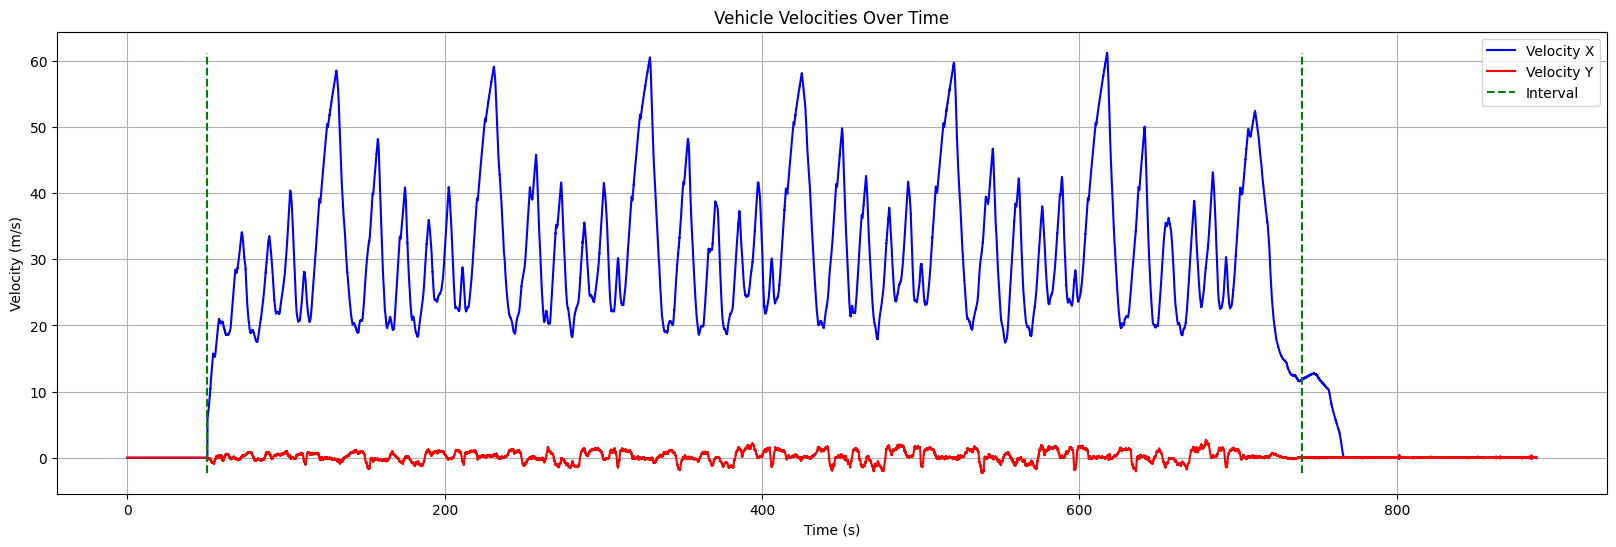

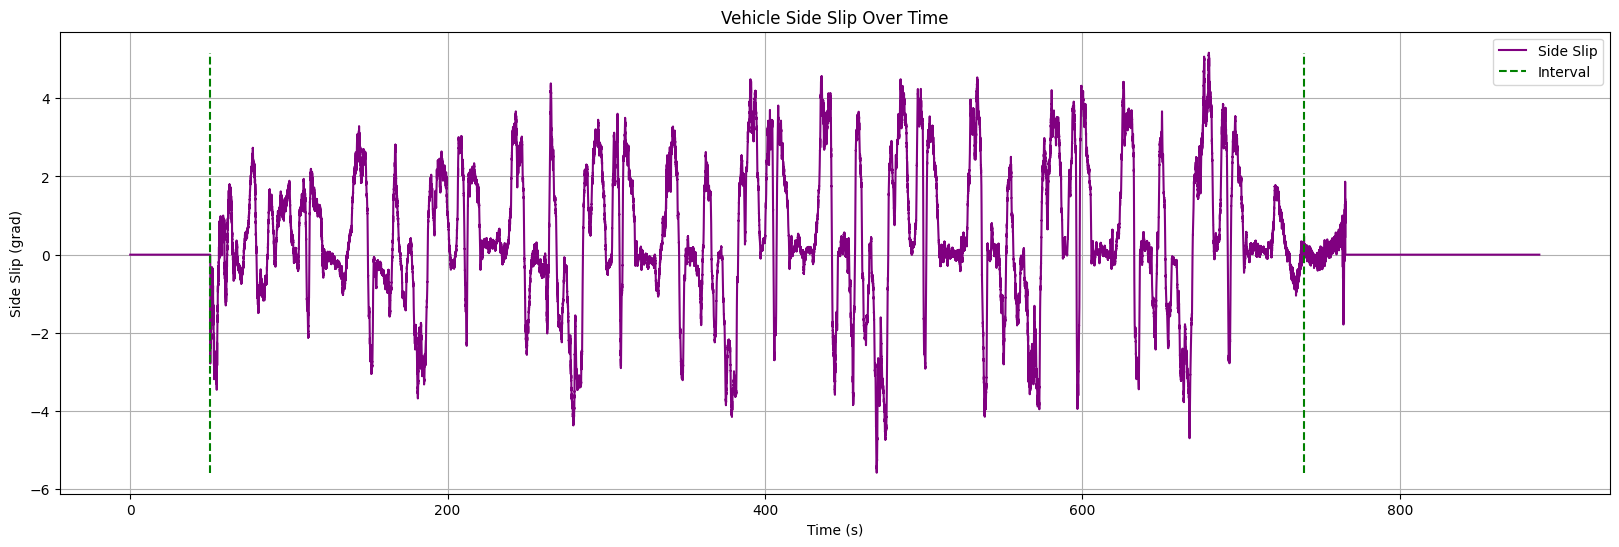

In [6]:
start_t=50
stop_t=start_t + 11.5*60
plot_data(test_data, start_t=start_t, stop_t=stop_t)

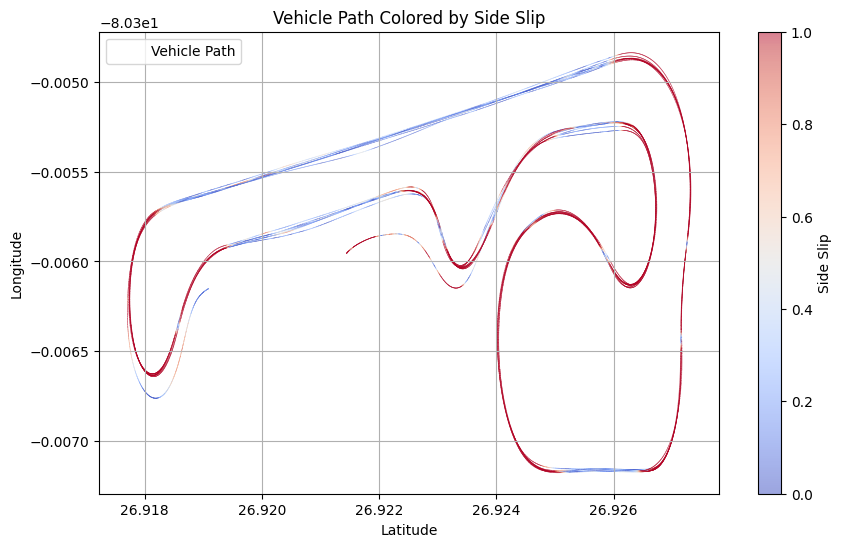

In [7]:
test_data = test_data[(test_data['time'] >= start_t) & (test_data['time'] <= stop_t)]

plot_vehicle_path(test_data)

In [8]:
save_to_file(test_data, 'processed_test_data.csv')

Data saved to processed_test_data.csv


# One Lap

___

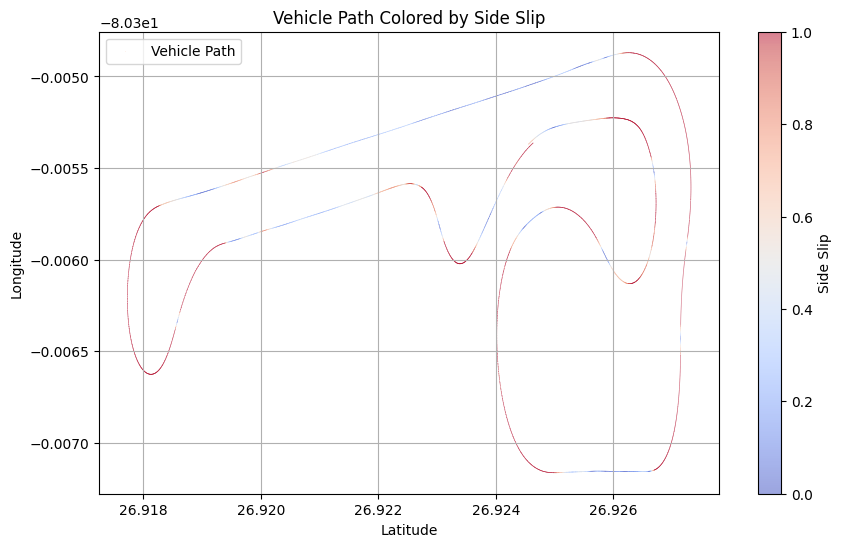

In [9]:
one_lap_data = test_data[(test_data['time'] >= 70) & (test_data['time'] <= 173)] #276
plot_vehicle_path(one_lap_data)

In [10]:
save_to_file(one_lap_data, 'processed_test_one_lap_data.csv')

Data saved to processed_test_one_lap_data.csv


# Train  data

In [11]:

train_file_path = r"C:\Users\msbka\PINNS\Dataset\20130222_01_02_03_grandsport.mat"
train_data = mat_to_pandas(train_file_path, features)
# Display the first few rows of the test DataFrame
print(train_data.head())

    latitude  longitude  sideSlip      vxCG      vyCG      axCG      ayCG  \
0  26.920794 -80.306057       0.0 -0.008763  0.004499  0.215831  0.571743   
1  26.920794 -80.306057       0.0 -0.008364  0.012522  0.009553 -0.654905   
2  26.920794 -80.306057       0.0 -0.007207  0.019551 -0.088390 -0.241379   
3  26.920794 -80.306057       0.0 -0.009070 -0.000904  0.063293  0.049130   
4  26.920794 -80.306057       0.0 -0.008928 -0.009824 -0.000731 -0.062028   

    yawRate  time  
0 -0.064669  0.00  
1  0.041858  0.01  
2  0.076798  0.02  
3 -0.026415  0.03  
4  0.006813  0.04  


In [12]:
#  Handle NaNs and Interpolate Missing Values

print(" NaN values before interpolation:\n")
print(train_data.isna().sum())

train_data.interpolate(method='linear', limit_direction='both', inplace=True)
train_data.fillna(0, inplace=True)

print("\n NaN values after interpolation and filling:\n")
print(train_data.isna().sum())


 NaN values before interpolation:

latitude     0
longitude    0
sideSlip     0
vxCG         0
vyCG         0
axCG         0
ayCG         0
yawRate      0
time         0
dtype: int64

 NaN values after interpolation and filling:

latitude     0
longitude    0
sideSlip     0
vxCG         0
vyCG         0
axCG         0
ayCG         0
yawRate      0
time         0
dtype: int64


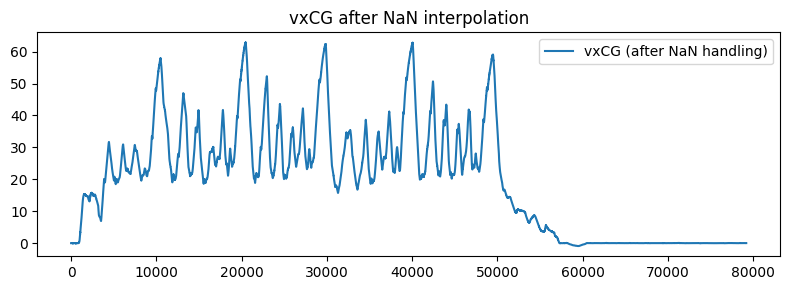

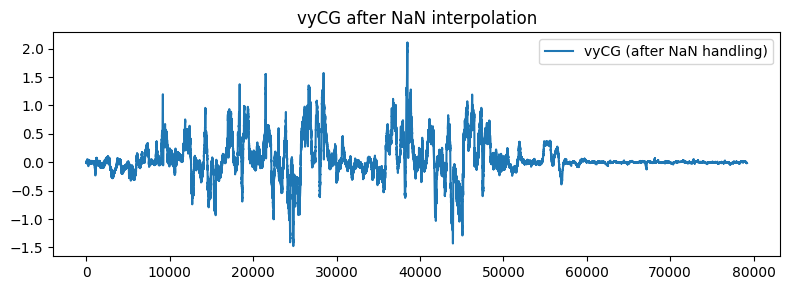

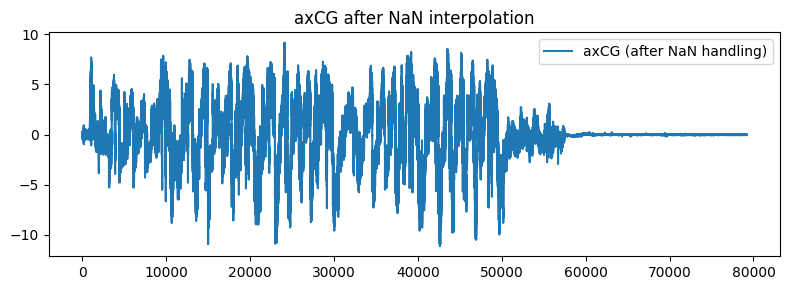

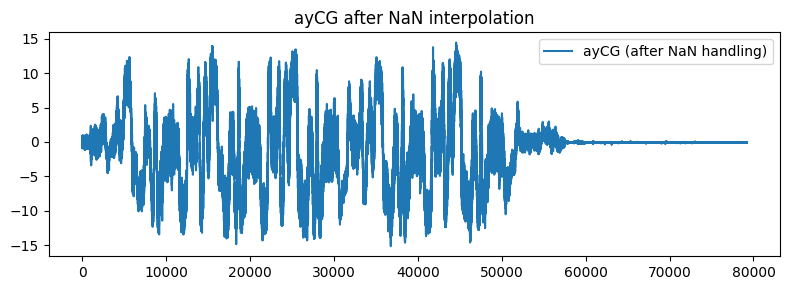

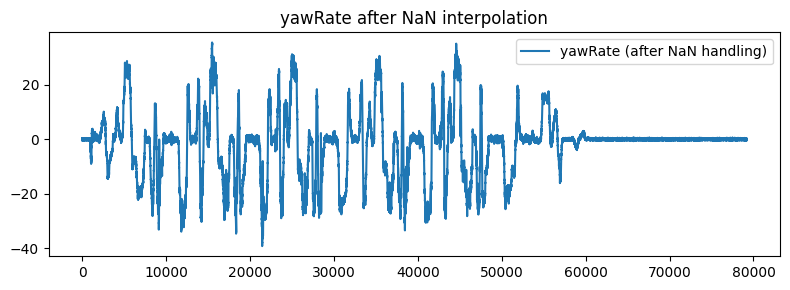

In [13]:
cols_to_plot = ['vxCG', 'vyCG', 'axCG', 'ayCG', 'yawRate']
for col in cols_to_plot:
    plt.figure(figsize=(8, 3))
    plt.plot(train_data[col].values, label=f'{col} (after NaN handling)')
    plt.title(f'{col} after NaN interpolation')
    plt.legend()
    plt.tight_layout()
    plt.show()


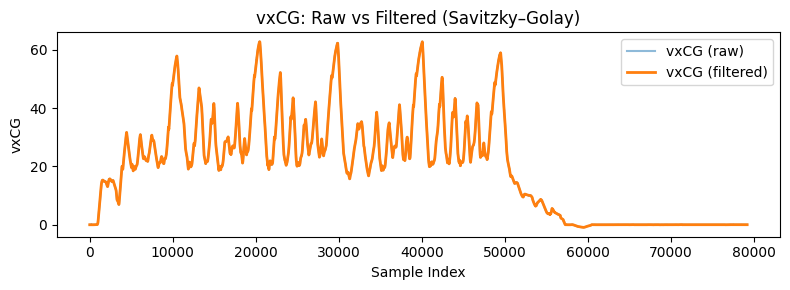

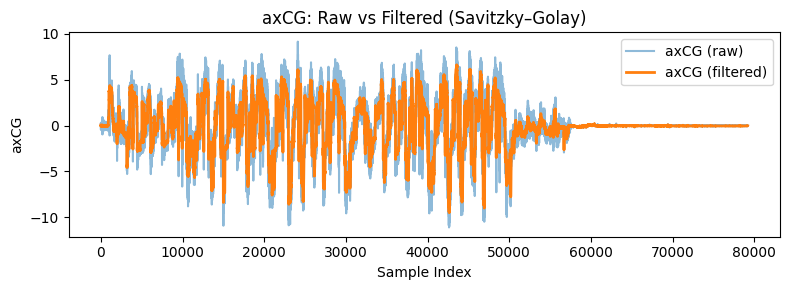

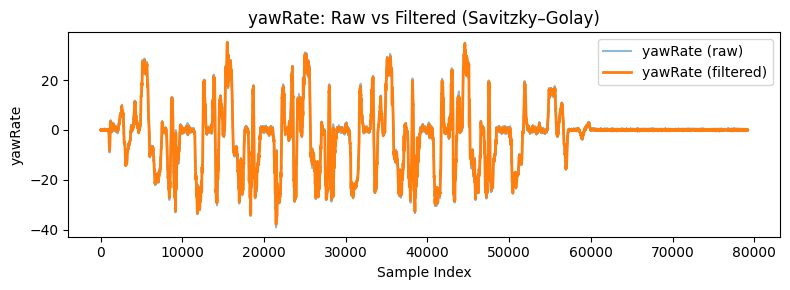

In [14]:

from scipy.signal import savgol_filter

# Define a helper function for smoothing
def smooth_signal(sig, window=31, poly=2):
   
    if window >= len(sig):
        window = len(sig) - 1 if len(sig) % 2 == 0 else len(sig)
    if window % 2 == 0:
        window += 1
    return savgol_filter(sig, window_length=window, polyorder=poly, mode='nearest')

# Columns to filter (core dynamics)
cols_to_filter = ['vxCG', 'vyCG', 'axCG', 'ayCG', 'yawRate']

# Apply filter and create new columns with "_filt" suffix
for col in cols_to_filter:
    train_data[col + '_filt'] = smooth_signal(train_data[col].values, window=31, poly=2)

# Quick comparison: plot before vs after for a few signals

for col in ['vxCG', 'axCG', 'yawRate']:
    plt.figure(figsize=(8, 3))
    plt.plot(train_data[col].values, label=f'{col} (raw)', alpha=0.5)
    plt.plot(train_data[col + "_filt"].values, label=f'{col} (filtered)', linewidth=2)
    plt.title(f"{col}: Raw vs Filtered (Savitzky–Golay)")
    plt.xlabel("Sample Index")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [15]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Prepare inputs and targets
# ------------------------------------------------------------
vx = train_data['vxCG_filt'].values
vy = train_data['vyCG_filt'].values
r  = train_data['yawRate_filt'].values
ax = train_data['axCG_filt'].values
ay = train_data['ayCG_filt'].values

# Input at time k : [vx, vy, r, ax, ay]
# Target at time k+1 : [vx_next, vy_next]
X = np.column_stack([vx[:-1], vy[:-1], r[:-1], ax[:-1], ay[:-1]])
Y = np.column_stack([vx[1:], vy[1:]])

print(f"Full dataset -> Inputs: {X.shape}, Targets: {Y.shape}")


X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

#  Create individual scalers for each feature
scaler_vx = MinMaxScaler(feature_range=(0, 1))   # vx always positive
scaler_vy = StandardScaler()                     # vy can be ±
scaler_r  = StandardScaler()                     # yawRate can be ±
scaler_ax = StandardScaler()                     # ax can be ±
scaler_ay = StandardScaler()                     # ay can be ±
scaler_Y  = StandardScaler()                     # output vx, vy can be ±


scaler_vx.fit(X_train[:, [0]])
scaler_vy.fit(X_train[:, [1]])
scaler_r.fit(X_train[:, [2]])
scaler_ax.fit(X_train[:, [3]])
scaler_ay.fit(X_train[:, [4]])
scaler_Y.fit(Y_train)

X_train_scaled = np.column_stack([
    scaler_vx.transform(X_train[:, [0]]),
    scaler_vy.transform(X_train[:, [1]]),
    scaler_r.transform(X_train[:, [2]]),
    scaler_ax.transform(X_train[:, [3]]),
    scaler_ay.transform(X_train[:, [4]]),
])
X_test_scaled = np.column_stack([
    scaler_vx.transform(X_test[:, [0]]),
    scaler_vy.transform(X_test[:, [1]]),
    scaler_r.transform(X_test[:, [2]]),
    scaler_ax.transform(X_test[:, [3]]),
    scaler_ay.transform(X_test[:, [4]]),
])
Y_train_scaled = scaler_Y.transform(Y_train)
Y_test_scaled  = scaler_Y.transform(Y_test)

print("Scaling complete.")
print("Scaled X_train sample:\n", np.round(X_train_scaled[:3], 3))
print("Scaled Y_train sample:\n", np.round(Y_train_scaled[:3], 3))


def transform_X(X):
    """Apply feature-wise scaling to any new input array."""
    return np.column_stack([
        scaler_vx.transform(X[:, [0]]),
        scaler_vy.transform(X[:, [1]]),
        scaler_r.transform(X[:, [2]]),
        scaler_ax.transform(X[:, [3]]),
        scaler_ay.transform(X[:, [4]]),
    ])

def inverse_transform_Y(Y_scaled):
    """Convert scaled outputs back to real physical units."""
    return scaler_Y.inverse_transform(Y_scaled)



class VehicleDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


train_dataset = VehicleDataset(X_train_scaled, Y_train_scaled)
test_dataset  = VehicleDataset(X_test_scaled,  Y_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(" Train/test split and scaled DataLoaders ready.")





Full dataset -> Inputs: (79199, 5), Targets: (79199, 2)
Training samples: 63359 | Testing samples: 15840
Scaling complete.
Scaled X_train sample:
 [[ 0.304 -0.323 -1.684  0.671 -1.314]
 [ 0.419  1.026 -0.868  1.267 -1.068]
 [ 0.594 -1.499  0.758  1.794  1.163]]
Scaled Y_train sample:
 [[-0.078 -0.32 ]
 [ 0.354  1.018]
 [ 1.016 -1.496]]
 Train/test split and scaled DataLoaders ready.


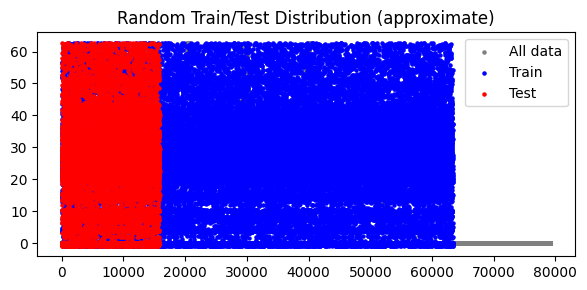

In [16]:
plt.figure(figsize=(6,3))
plt.scatter(range(len(vx)-1), vx[:-1], c='gray', s=5, label='All data')
plt.scatter(range(len(X_train)), X_train[:,0], c='blue', s=5, label='Train')
plt.scatter(range(len(X_test)), X_test[:,0], c='red', s=5, label='Test')
plt.title("Random Train/Test Distribution (approximate)")
plt.legend()
plt.tight_layout()
plt.show()


VehicleNN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
Epoch [1/50] | Train Loss: 0.067335 | Test Loss: 0.001245
Epoch [2/50] | Train Loss: 0.000877 | Test Loss: 0.000723
Epoch [3/50] | Train Loss: 0.000489 | Test Loss: 0.000347
Epoch [4/50] | Train Loss: 0.000337 | Test Loss: 0.000264
Epoch [5/50] | Train Loss: 0.000266 | Test Loss: 0.000200
Epoch [6/50] | Train Loss: 0.000214 | Test Loss: 0.000219
Epoch [7/50] | Train Loss: 0.000198 | Test Loss: 0.000175
Epoch [8/50] | Train Loss: 0.000186 | Test Loss: 0.000128
Epoch [9/50] | Train Loss: 0.000159 | Test Loss: 0.000121
Epoch [10/50] | Train Loss: 0.000136 | Test Loss: 0.000176
Epoch [11/50] | Train Loss: 0.000143 | Test Loss: 0.000156
Epoch [12/50] | Train Loss: 0.000129 | Test Loss: 0.000131
Epoch [13/50] | Train Loss: 0.000127 | Test Loss: 0.0

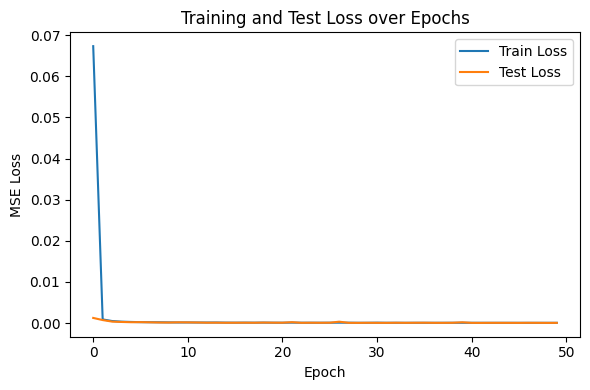

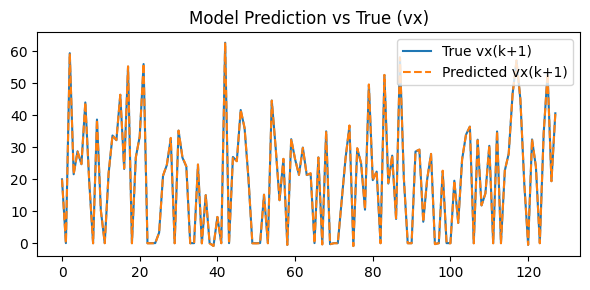

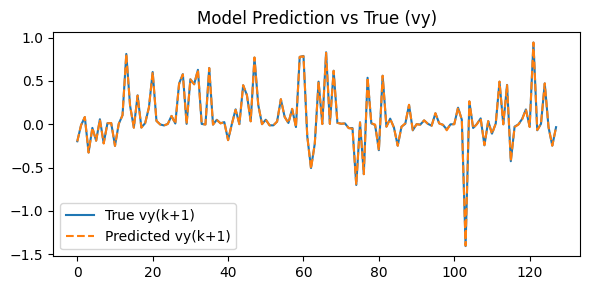

In [17]:

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

#  Define the Neural Network Architecture ===
class VehicleNN(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=64, output_dim=2):
        super(VehicleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

model = VehicleNN()
print(model)

#  Define Loss Function and Optimizer
criterion = nn.MSELoss()                     # Mean squared error
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training Loop
num_epochs = 50
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluate on test set
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, Y_batch)
            test_loss += loss.item()
    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")

print(" Training complete.")

# ===  Plot Loss Curves ===
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title("Training and Test Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    X_test_sample, Y_test_sample = next(iter(test_loader))
    Y_pred_scaled = model(X_test_sample).detach().numpy()
    Y_true_scaled = Y_test_sample.numpy()

# Inverse-transform from scaled to real units
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled)
Y_true = scaler_Y.inverse_transform(Y_true_scaled)

# --- Plot vx(k+1) ---
plt.figure(figsize=(6,3))
plt.plot(Y_true[:200,0], label='True vx(k+1)')
plt.plot(Y_pred[:200,0], label='Predicted vx(k+1)', linestyle='--')
plt.title("Model Prediction vs True (vx)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot vy(k+1) ---
plt.figure(figsize=(6,3))
plt.plot(Y_true[:200,1], label='True vy(k+1)')
plt.plot(Y_pred[:200,1], label='Predicted vy(k+1)', linestyle='--')
plt.title("Model Prediction vs True (vy)")
plt.legend()
plt.tight_layout()
plt.show()


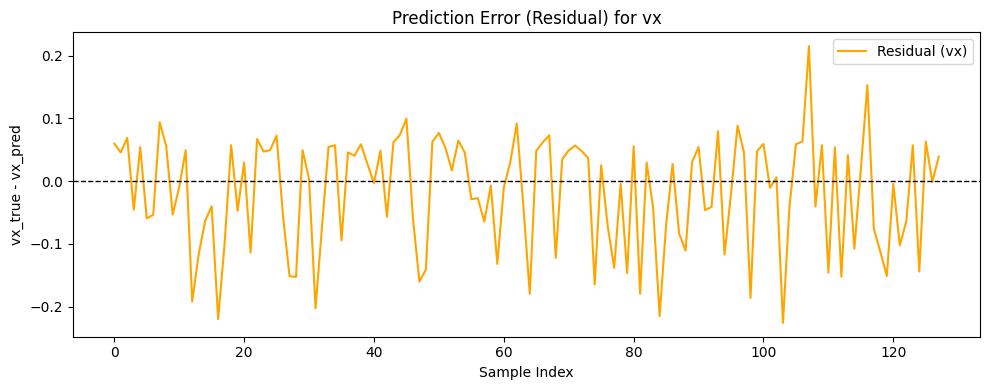

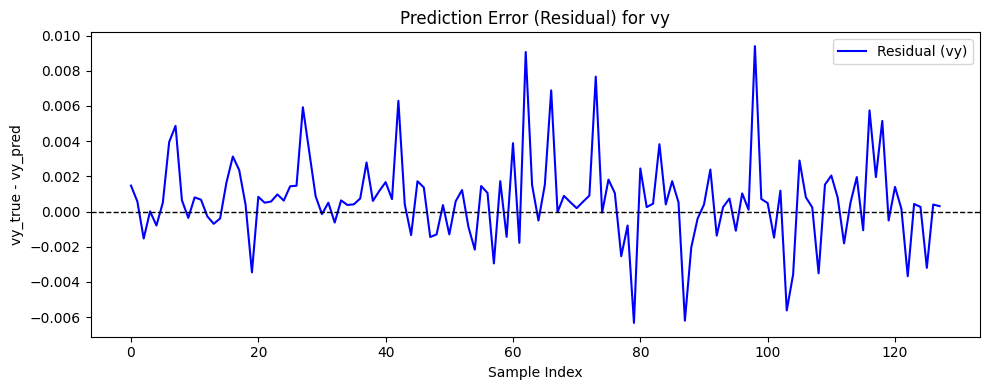

vx Residuals → Mean: -0.017876, Std: 0.088622, RMSE: 0.090407
vy Residuals → Mean: 0.000656, Std: 0.002459, RMSE: 0.002545


In [18]:

import matplotlib.pyplot as plt
import numpy as np

# Compute residuals (difference between true and predicted)
residual_vx = Y_true[:, 0] - Y_pred[:, 0]
residual_vy = Y_true[:, 1] - Y_pred[:, 1]

# Plot residuals over sample index
plt.figure(figsize=(10, 4))
plt.plot(residual_vx, label='Residual (vx)', color='orange')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Prediction Error (Residual) for vx")
plt.xlabel("Sample Index")
plt.ylabel("vx_true - vx_pred")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(residual_vy, label='Residual (vy)', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Prediction Error (Residual) for vy")
plt.xlabel("Sample Index")
plt.ylabel("vy_true - vy_pred")
plt.legend()
plt.tight_layout()
plt.show()


def residual_stats(name, residuals):
    mean_err = np.mean(residuals)
    std_err = np.std(residuals)
    rmse = np.sqrt(np.mean(residuals**2))
    print(f"{name} Residuals → Mean: {mean_err:.6f}, Std: {std_err:.6f}, RMSE: {rmse:.6f}")

residual_stats("vx", residual_vx)
residual_stats("vy", residual_vy)


In [19]:

# Kinematic Vehicle Model (KVM) Solver

import torch

def physics_next_state(vx, vy, r, ax, ay, dt=0.01):
    

    vx_next = vx + dt * (ax - r * vy)
    vy_next = vy + dt * (ay + r * vx)
    return vx_next, vy_next

# Quick sanity check
vx0 = torch.tensor([20.0])
vy0 = torch.tensor([0.5])
r0  = torch.tensor([0.1])
ax0 = torch.tensor([2.0])
ay0 = torch.tensor([-0.5])

vx_next, vy_next = physics_next_state(vx0, vy0, r0, ax0, ay0)
print(f"vx_next: {vx_next.item():.3f}, vy_next: {vy_next.item():.3f}")


vx_next: 20.020, vy_next: 0.515


In [20]:

from scipy.stats import qmc
import numpy as np

def generate_initial_conditions(N_phys=5):
    

    sampler = qmc.LatinHypercube(d=5)
    sample = sampler.random(n=N_phys)
    
    # physical bounds for each variable
    # [vx, vy, r, ax, ay]
    l_bounds = [0,  -8,  -20, -40, -50]   # lower limits
    u_bounds = [70,  8,   20,  40,  50]   # upper limits

    initial_conditions = qmc.scale(sample, l_bounds, u_bounds)
    return initial_conditions

#
X_phys_small = generate_initial_conditions(N_phys=4)
print(" Random Physics Points Generated (small test set)")
print("Shape:", X_phys_small.shape)
print("Generated Points:\n", np.round(X_phys_small, 3))



 Random Physics Points Generated (small test set)
Shape: (4, 5)
Generated Points:
 [[ 55.491  -0.41    6.542  38.403  39.997]
 [ 25.553  -4.02  -14.167  -5.56   14.626]
 [  7.145   3.837  10.88  -30.879  -1.777]
 [ 38.428   6.34   -2.861  15.981 -45.754]]


In [21]:
scaler_X = StandardScaler()


In [22]:

#  SCALE RANDOM POINTS

N_phys = 4  # or 5 for now (start small for testing)
X_phys_real = generate_initial_conditions(N_phys)

print(" Random Physics Points (Real Units):")
print(np.round(X_phys_real, 3))

# --- Scale them using the same feature-wise scalers ---
X_phys_scaled = transform_X(X_phys_real)

print("\n Random Physics Points (Scaled Units):")
print(np.round(X_phys_scaled, 3))

# --- Sanity check ---
print(f"\nShape of X_phys_real:   {X_phys_real.shape}")
print(f"Shape of X_phys_scaled: {X_phys_scaled.shape}")




 Random Physics Points (Real Units):
[[  6.706  -3.554  -2.2   -16.301 -10.821]
 [ 44.956  -5.377 -15.361 -26.718 -47.774]
 [ 67.028   7.27   15.435  34.744  48.528]
 [ 26.23    3.488   3.589  14.137   5.162]]

 Random Physics Points (Scaled Units):
[[ 1.2000e-01 -1.1707e+01 -8.0000e-03 -6.4320e+00 -2.1230e+00]
 [ 7.2000e-01 -1.7619e+01 -1.1360e+00 -1.0532e+01 -1.0128e+01]
 [ 1.0660e+00  2.3394e+01  1.5050e+00  1.3658e+01  1.0733e+01]
 [ 4.2600e-01  1.1128e+01  4.8900e-01  5.5470e+00  1.3390e+00]]

Shape of X_phys_real:   (4, 5)
Shape of X_phys_scaled: (4, 5)


In [23]:
#Physics Loss 

import torch
import numpy as np
import matplotlib.pyplot as plt

def compute_physics_loss(model, X_phys_real, X_phys_scaled, dt=0.01, debug=False):
    
    #  Convert to tensors
    X_phys_scaled_t = torch.tensor(X_phys_scaled, dtype=torch.float32)
    X_phys_real_t   = torch.tensor(X_phys_real, dtype=torch.float32)

    # NN prediction (scaled → real physical units)
    with torch.no_grad():
        Y_pred_scaled = model(X_phys_scaled_t).numpy()
    # inverse transform from scaled to real units (m/s)
    Y_pred_real = inverse_transform_Y(Y_pred_scaled)

    # Physics next state (using KVM solver) 
    vx, vy, r, ax, ay = [X_phys_real_t[:, i] for i in range(5)]
    vx_next_phys, vy_next_phys = physics_next_state(vx, vy, r, ax, ay, dt)
    Y_phys_next = torch.stack([vx_next_phys, vy_next_phys], dim=1).numpy()

    # ---  Compute residuals (NN - Physics) ---
    fx = Y_pred_real[:, 0] - Y_phys_next[:, 0]  # vx residual
    fy = Y_pred_real[:, 1] - Y_phys_next[:, 1]  # vy residual

    # ---  Physics loss (Mean Squared Error) ---
    L_phys = np.mean(fx**2 + fy**2)

    # debug output ---
    if debug:
        print("\n Debug Info:")
        print("NN predictions (real units):\n", np.round(Y_pred_real, 3))
        print("Physics next state (real units):\n", np.round(Y_phys_next, 3))
        print("Residual fx (vx diff):", np.round(fx, 3))
        print("Residual fy (vy diff):", np.round(fy, 3))

    return fx, fy, L_phys


# ---- Run it ----
fx, fy, L_phys = compute_physics_loss(model, X_phys_real, X_phys_scaled, dt=0.01, debug=True)
print(f"\n Physics-only loss computed (N={len(X_phys_real)}): {L_phys:.6f}")



 Debug Info:
NN predictions (real units):
 [[-12.188  -3.085]
 [-29.961  -4.437]
 [ 35.222   6.587]
 [ 23.97    3.223]]
Physics next state (real units):
 [[  6.465  -3.81 ]
 [ 43.863 -12.761]
 [ 66.253  18.102]
 [ 26.246   4.481]]
Residual fx (vx diff): [-18.653 -73.824 -31.031  -2.275]
Residual fy (vy diff): [  0.725   8.324 -11.515  -1.257]

 Physics-only loss computed (N=4): 1742.504395


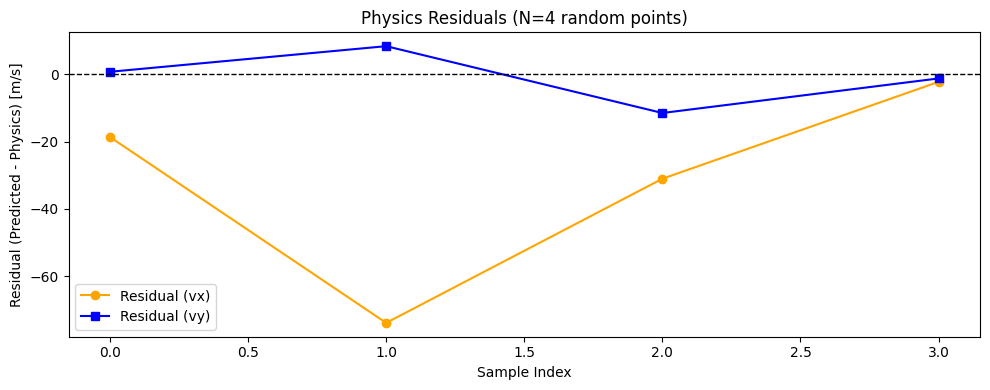

vx Residuals → Mean: -31.445904, Std: 26.507814, RMSE: 41.127960
vy Residuals → Mean: -0.930792, Std: 7.080169, RMSE: 7.141090


In [24]:
# ============================================================
# 🔹 STEP: PLOT PHYSICS RESIDUALS
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(fx, 'o-', label='Residual (vx)', color='orange')
plt.plot(fy, 's-', label='Residual (vy)', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title(f"Physics Residuals (N={len(fx)} random points)")
plt.xlabel("Sample Index")
plt.ylabel("Residual (Predicted - Physics) [m/s]")
plt.legend()
plt.tight_layout()
plt.show()

# --- Print summary stats ---
def residual_stats(name, residuals):
    mean_err = np.mean(residuals)
    std_err  = np.std(residuals)
    rmse     = np.sqrt(np.mean(residuals**2))
    print(f"{name} Residuals → Mean: {mean_err:.6f}, Std: {std_err:.6f}, RMSE: {rmse:.6f}")

residual_stats("vx", fx)
residual_stats("vy", fy)


In [25]:

#   SETUP

import torch
import numpy as np
import math
import matplotlib.pyplot as plt

# Device setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# --- Base hyperparameter function ---
def get_hyperparams(num_epochs=50, 
                    w_data=1.0, 
                    w_phys_init=0.1, 
                    decay_rate=0.03, 
                    N_phys=64, 
                    dt=0.01, 
                    lr=1e-3):
   
    return {
        "num_epochs": num_epochs,
        "w_data": w_data,
        "w_phys_init": w_phys_init,
        "decay_rate": decay_rate,
        "N_phys": N_phys,
        "dt": dt,
        "lr": lr
    }

print("  Device ready:", device)
print(" Hyperparameter manager created.")


  Device ready: cpu
 Hyperparameter manager created.


In [26]:

def compute_physics_loss_torch(model, N_phys, dt, device):
   
    # Generate random samples (real + scaled)
    X_phys_real = generate_initial_conditions(N_phys)
    X_phys_scaled = transform_X(X_phys_real)

    X_phys_scaled_t = torch.tensor(X_phys_scaled, dtype=torch.float32, device=device)
    X_phys_real_t   = torch.tensor(X_phys_real, dtype=torch.float32, device=device)

    # NN prediction on scaled input
    Y_pred_scaled = model(X_phys_scaled_t)

    # Inverse scale to real units
    scale_tensor = torch.tensor(scaler_Y.scale_, dtype=torch.float32, device=device)
    mean_tensor  = torch.tensor(scaler_Y.mean_, dtype=torch.float32, device=device)
    Y_pred_real  = Y_pred_scaled * scale_tensor + mean_tensor

    # Compute next state using kinematic model
    vx, vy, r, ax, ay = [X_phys_real_t[:, i] for i in range(5)]
    vx_next_phys, vy_next_phys = physics_next_state(vx, vy, r, ax, ay, dt)
    Y_phys_next = torch.stack([vx_next_phys, vy_next_phys], dim=1)

    # Physics loss (MSE)
    loss_phys = torch.mean((Y_pred_real - Y_phys_next)**2)
    return loss_phys


In [27]:

def train_pinn(model, params, train_loader, device):
   
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
    criterion = torch.nn.MSELoss()

    num_epochs = params["num_epochs"]
    w_data = params["w_data"]
    w_phys_init = params["w_phys_init"]
    decay_rate = params["decay_rate"]
    N_phys = params["N_phys"]
    dt = params["dt"]

    data_losses, phys_losses, total_losses = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_data_loss = 0.0
        running_phys_loss = 0.0
        running_total_loss = 0.0

        # Exponential decay for physics weight
        w_phys = w_phys_init * math.exp(-decay_rate * epoch)

        for X_batch, Y_batch in train_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            optimizer.zero_grad()

            #  Data loss 
            Y_pred = model(X_batch)
            loss_data = criterion(Y_pred, Y_batch)

            #  Physics loss
            loss_phys = compute_physics_loss_torch(model, N_phys, dt, device)

            # Combined total loss
            loss_total = w_data * loss_data + w_phys * loss_phys
            loss_total.backward()
            optimizer.step()

            running_data_loss += loss_data.item()
            running_phys_loss += loss_phys.item()
            running_total_loss += loss_total.item()

        #  Average per epoch
        avg_data_loss  = running_data_loss / len(train_loader)
        avg_phys_loss  = running_phys_loss / len(train_loader)
        avg_total_loss = running_total_loss / len(train_loader)

        data_losses.append(avg_data_loss)
        phys_losses.append(avg_phys_loss)
        total_losses.append(avg_total_loss)

        print(f"Epoch [{epoch+1:02d}/{num_epochs}] | "
              f"Data: {avg_data_loss:.6f} | "
              f"Physics: {avg_phys_loss:.6f} | "
              f"Total: {avg_total_loss:.6f} | "
              f"w_phys={w_phys:.4f} | N_phys={N_phys}")

    print(" Training complete.")
    return data_losses, phys_losses, total_losses



In [28]:
#

N_phys_values = [4,64,512]   # try different number of physics points
results = {}

for n_phys in N_phys_values:
    print(f"\n Training with N_phys = {n_phys}")
    params = get_hyperparams(num_epochs=50, 
                             w_data=1.0,
                             w_phys_init=0.1,
                             decay_rate=0.03,
                             N_phys=n_phys,
                             dt=0.01,
                             lr=1e-2)

    # reinitialize a new model each run
    model_exp = VehicleNN().to(device)
    data_l, phys_l, total_l = train_pinn(model_exp, params, train_loader, device)
    results[n_phys] = {"data": data_l, "phys": phys_l, "total": total_l}




 Training with N_phys = 4
Epoch [01/50] | Data: 0.350307 | Physics: 109.793135 | Total: 11.329621 | w_phys=0.1000 | N_phys=4
Epoch [02/50] | Data: 0.064372 | Physics: 9.343685 | Total: 0.971126 | w_phys=0.0970 | N_phys=4
Epoch [03/50] | Data: 0.039067 | Physics: 3.197866 | Total: 0.340230 | w_phys=0.0942 | N_phys=4
Epoch [04/50] | Data: 0.025867 | Physics: 2.206854 | Total: 0.227559 | w_phys=0.0914 | N_phys=4
Epoch [05/50] | Data: 0.021208 | Physics: 2.274390 | Total: 0.222928 | w_phys=0.0887 | N_phys=4
Epoch [06/50] | Data: 0.014652 | Physics: 1.527476 | Total: 0.146123 | w_phys=0.0861 | N_phys=4
Epoch [07/50] | Data: 0.016548 | Physics: 1.706277 | Total: 0.159068 | w_phys=0.0835 | N_phys=4
Epoch [08/50] | Data: 0.018809 | Physics: 2.495686 | Total: 0.221105 | w_phys=0.0811 | N_phys=4
Epoch [09/50] | Data: 0.015581 | Physics: 1.048699 | Total: 0.098075 | w_phys=0.0787 | N_phys=4
Epoch [10/50] | Data: 0.025766 | Physics: 2.623175 | Total: 0.226014 | w_phys=0.0763 | N_phys=4
Epoch [11/

___

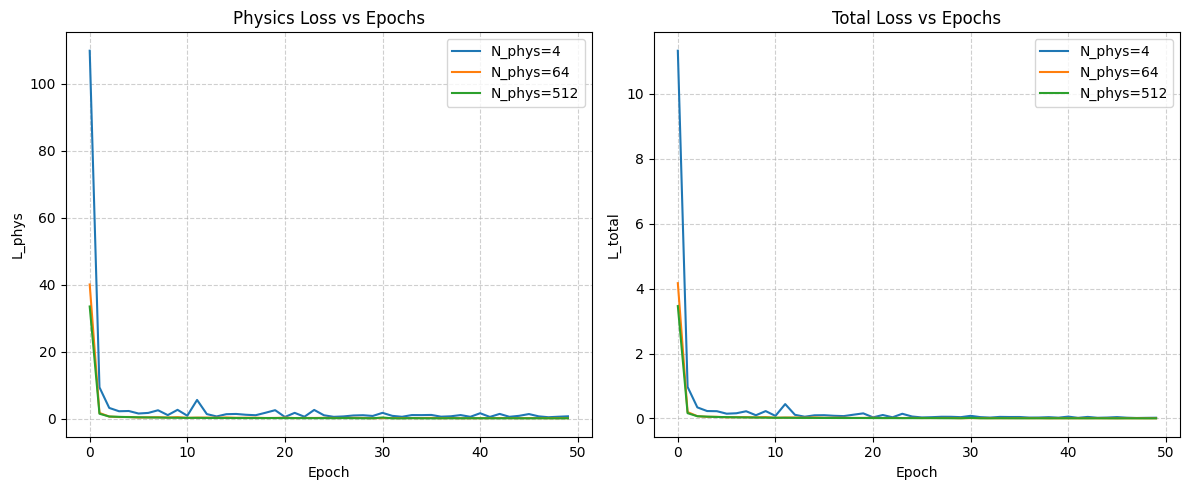

In [29]:

plt.figure(figsize=(12,5))

#  Physics Loss 
plt.subplot(1,2,1)
for n, res in results.items():
    plt.plot(res["phys"], label=f"N_phys={n}")
plt.title("Physics Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("L_phys")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

#  Total Loss
plt.subplot(1,2,2)
for n, res in results.items():
    plt.plot(res["total"], label=f"N_phys={n}")
plt.title("Total Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("L_total")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



In [30]:


decay_values = [0.0,  0.03, 0.1]   # Try different decay rates
results_decay = {}

for decay in decay_values:
    print(f"\n🚀 Training with decay_rate = {decay}")
    params = get_hyperparams(num_epochs=50,
                             w_data=1.0,
                             w_phys_init=0.1,
                             decay_rate=decay,
                             N_phys=64,       # keep this fixed for fairness
                             dt=0.01,
                             lr=1e-2)

    # Reinitialize a new model each run
    model_exp = VehicleNN().to(device)
    data_l, phys_l, total_l = train_pinn(model_exp, params, train_loader, device)
    results_decay[decay] = {"data": data_l, "phys": phys_l, "total": total_l}



🚀 Training with decay_rate = 0.0
Epoch [01/50] | Data: 0.246173 | Physics: 66.916490 | Total: 6.937822 | w_phys=0.1000 | N_phys=64
Epoch [02/50] | Data: 0.053559 | Physics: 3.508237 | Total: 0.404382 | w_phys=0.1000 | N_phys=64
Epoch [03/50] | Data: 0.049383 | Physics: 1.662426 | Total: 0.215626 | w_phys=0.1000 | N_phys=64
Epoch [04/50] | Data: 0.035509 | Physics: 0.841104 | Total: 0.119619 | w_phys=0.1000 | N_phys=64
Epoch [05/50] | Data: 0.027922 | Physics: 0.574566 | Total: 0.085378 | w_phys=0.1000 | N_phys=64
Epoch [06/50] | Data: 0.023830 | Physics: 0.436852 | Total: 0.067515 | w_phys=0.1000 | N_phys=64
Epoch [07/50] | Data: 0.020405 | Physics: 0.409926 | Total: 0.061398 | w_phys=0.1000 | N_phys=64
Epoch [08/50] | Data: 0.020032 | Physics: 0.346440 | Total: 0.054676 | w_phys=0.1000 | N_phys=64
Epoch [09/50] | Data: 0.013407 | Physics: 0.313897 | Total: 0.044797 | w_phys=0.1000 | N_phys=64
Epoch [10/50] | Data: 0.011163 | Physics: 0.264166 | Total: 0.037580 | w_phys=0.1000 | N_phy

KeyboardInterrupt: 

C:\Users\msbka\AppData\Local\Temp\ipykernel_9976\2023678935.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\msbka\AppData\Local\Temp\ipykernel_9976\2023678935.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


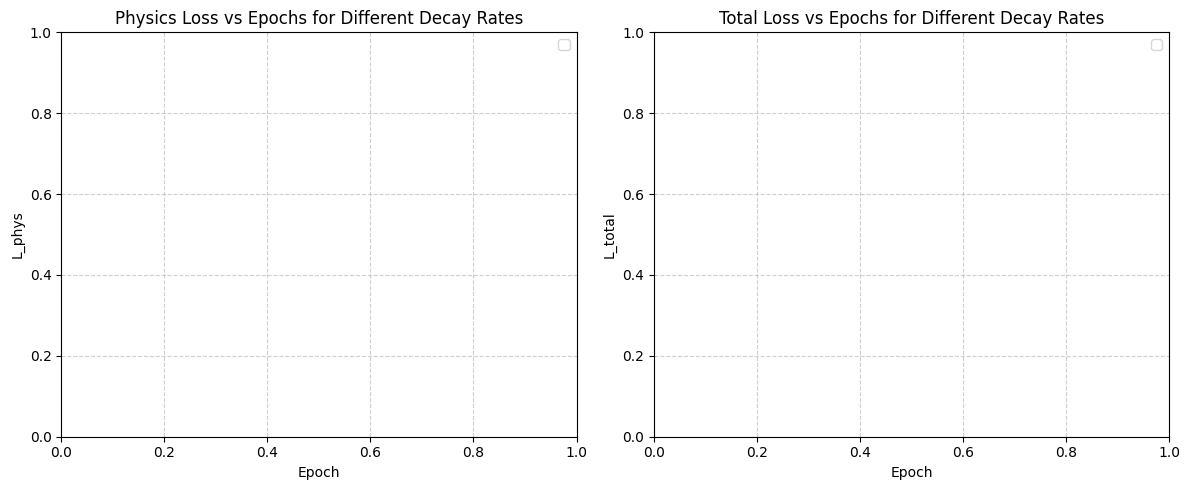

In [31]:
#Decay rate visulaization
plt.figure(figsize=(12,5))

# --- Physics Loss ---
plt.subplot(1,2,1)
for decay, res in results_decay.items():
    plt.plot(res["phys"], label=f"decay={decay}")
plt.title("Physics Loss vs Epochs for Different Decay Rates")
plt.xlabel("Epoch")
plt.ylabel("L_phys")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# --- Total Loss ---
plt.subplot(1,2,2)
for decay, res in results_decay.items():
    plt.plot(res["total"], label=f"decay={decay}")
plt.title("Total Loss vs Epochs for Different Decay Rates")
plt.xlabel("Epoch")
plt.ylabel("L_total")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [32]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    Y_test_t = torch.tensor(Y_test_scaled, dtype=torch.float32).to(device)

    # NN prediction (scaled output)
    Y_pred_scaled = model(X_test_t)

    #  Convert predictions to real physical units (m/s)
    scale_tensor = torch.tensor(scaler_Y.scale_, dtype=torch.float32, device=device)
    mean_tensor  = torch.tensor(scaler_Y.mean_, dtype=torch.float32, device=device)
    Y_pred_real = (Y_pred_scaled * scale_tensor + mean_tensor).cpu().numpy()


    Y_true_real = scaler_Y.inverse_transform(Y_test_scaled)

# Compute metrics
mse_vx = mean_squared_error(Y_true_real[:,0], Y_pred_real[:,0])
mse_vy = mean_squared_error(Y_true_real[:,1], Y_pred_real[:,1])
r2_vx  = r2_score(Y_true_real[:,0], Y_pred_real[:,0])
r2_vy  = r2_score(Y_true_real[:,1], Y_pred_real[:,1])

print(" Test Data Evaluation Results:")
print(f"MSE(vx): {mse_vx:.6f} | R²(vx): {r2_vx:.4f}")
print(f"MSE(vy): {mse_vy:.6f} | R²(vy): {r2_vy:.4f}")


 Test Data Evaluation Results:
MSE(vx): 0.009647 | R²(vx): 1.0000
MSE(vy): 0.000005 | R²(vy): 0.9999


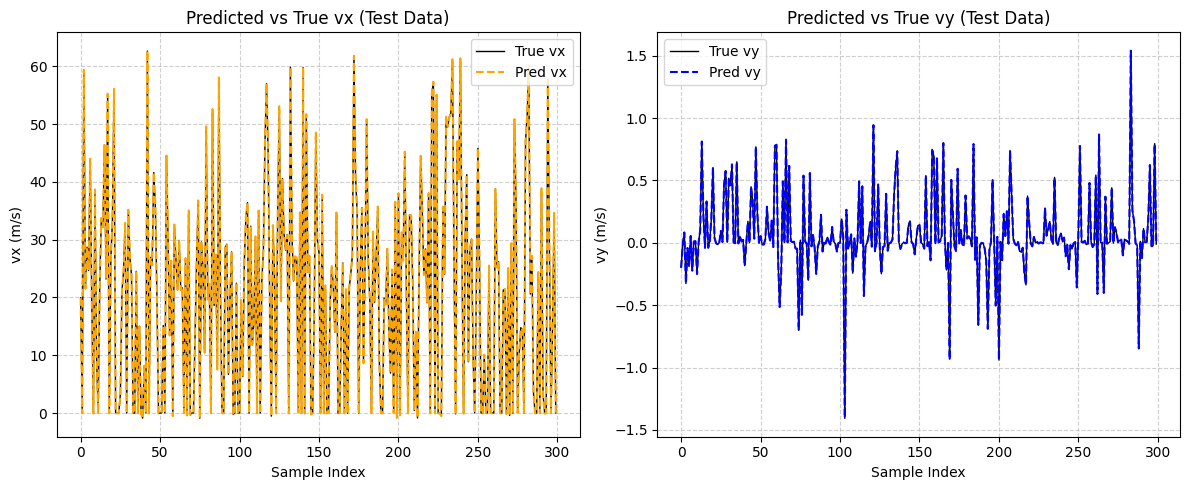

In [33]:


plt.figure(figsize=(12,5))

#  vx
plt.subplot(1,2,1)
plt.plot(Y_true_real[:300,0], label='True vx', color='black', linewidth=1)
plt.plot(Y_pred_real[:300,0], '--', label='Pred vx', color='orange')
plt.title("Predicted vs True vx (Test Data)")
plt.xlabel("Sample Index")
plt.ylabel("vx (m/s)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

#  vy 
plt.subplot(1,2,2)
plt.plot(Y_true_real[:300,1], label='True vy', color='black', linewidth=1)
plt.plot(Y_pred_real[:300,1], '--', label='Pred vy', color='blue')
plt.title("Predicted vs True vy (Test Data)")
plt.xlabel("Sample Index")
plt.ylabel("vy (m/s)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


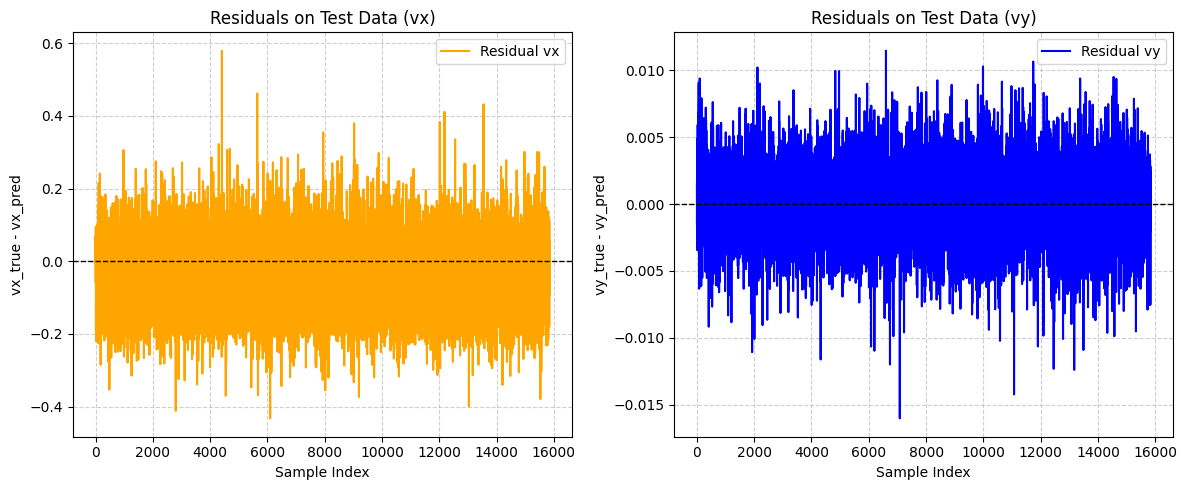

Residual stats (Test Data):
vx → mean: -0.0155, std: 0.0970, RMSE: 0.0982
vy → mean: 0.0003, std: 0.0022, RMSE: 0.0022


In [34]:

res_vx = Y_true_real[:,0] - Y_pred_real[:,0]
res_vy = Y_true_real[:,1] - Y_pred_real[:,1]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(res_vx, label='Residual vx', color='orange')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Residuals on Test Data (vx)")
plt.xlabel("Sample Index")
plt.ylabel("vx_true - vx_pred")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1,2,2)
plt.plot(res_vy, label='Residual vy', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Residuals on Test Data (vy)")
plt.xlabel("Sample Index")
plt.ylabel("vy_true - vy_pred")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#  Residual stats 
print("Residual stats (Test Data):")
print(f"vx → mean: {np.mean(res_vx):.4f}, std: {np.std(res_vx):.4f}, RMSE: {np.sqrt(np.mean(res_vx**2)):.4f}")
print(f"vy → mean: {np.mean(res_vy):.4f}, std: {np.std(res_vy):.4f}, RMSE: {np.sqrt(np.mean(res_vy**2)):.4f}")


In [ ]:
!{sys.executable} -m pip install -q "ray[tune]" pydantic pandas tqdm


'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


### TASK 3... Hyper Parameter Tuning Using Raytune



In [35]:
from ray import tune
from ray.tune.schedulers import ASHAScheduler
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# Split train → inner_train + val (for tuning)
X_tr, X_val, Y_tr, Y_val = train_test_split(
    X_train_scaled, Y_train_scaled, test_size=0.2, random_state=42, shuffle=True
)

train_inner_loader = DataLoader(
    TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                  torch.tensor(Y_tr, dtype=torch.float32)),
    batch_size=128, shuffle=True
)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                  torch.tensor(Y_val, dtype=torch.float32)),
    batch_size=128, shuffle=False
)


In [36]:
import math, torch.nn as nn

@torch.no_grad()
def eval_val_total_loss(model, params, val_loader, device):
    model.eval()
    criterion = nn.MSELoss()
    data_loss_sum = 0.0
    for Xb, Yb in val_loader:
        Xb, Yb = Xb.to(device), Yb.to(device)
        data_loss_sum += criterion(model(Xb), Yb).item()
    L_data_val = data_loss_sum / len(val_loader)

    L_phys_val = compute_physics_loss_torch(model, params["N_phys"], params["dt"], device).item()
    w_phys_last = params["w_phys_init"] * math.exp(-params["decay_rate"] * (params["num_epochs"] - 1))
    L_total_val = params["w_data"]*L_data_val + w_phys_last*L_phys_val
    return L_total_val, L_data_val, L_phys_val


In [37]:
def trainable_ray_tune(config):
    num_epochs   = config.get("num_epochs", 35)
    lr           = config["lr"]
    w_phys_init  = config["w_phys_init"]
    decay_rate   = config["decay_rate"]
    N_phys       = config["N_phys"]
    hidden_dim   = config["hidden_dim"]

    # Build model and optimizer
    model = VehicleNN(input_dim=5, hidden_dim=hidden_dim, output_dim=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # Params for physics functions
    params = dict(num_epochs=num_epochs, w_data=1.0, w_phys_init=w_phys_init,
                  decay_rate=decay_rate, N_phys=N_phys, dt=0.01, lr=lr)

    for epoch in range(num_epochs):
        model.train()
        w_phys = w_phys_init * math.exp(-decay_rate * epoch)
        total_loss = 0.0
        for Xb, Yb in train_inner_loader:
            Xb, Yb = Xb.to(device), Yb.to(device)
            optimizer.zero_grad()
            Yhat = model(Xb)
            Ld = criterion(Yhat, Yb)
            Lp = compute_physics_loss_torch(model, N_phys, params["dt"], device)
            Lt = Ld + w_phys * Lp
            Lt.backward()
            optimizer.step()
            total_loss += Lt.item()

        # Validation losses
        val_total, val_data, val_phys = eval_val_total_loss(model, params, val_loader, device)

        tune.report(epoch=epoch+1, val_total=val_total, val_data=val_data, val_phys=val_phys)


In [38]:
search_space = {
    "num_epochs": 35,
    "lr": tune.loguniform(1e-4, 1e-2),
    "w_phys_init": tune.uniform(0.05, 0.3),
    "decay_rate": tune.choice([0.0, 0.01, 0.03, 0.05]),
    "N_phys": tune.choice([32, 64, 128, 256]),
    "hidden_dim": tune.choice([64, 128])
}

scheduler = ASHAScheduler(metric="val_total", mode="min", grace_period=8, reduction_factor=2)


In [62]:
import os
tune_dir = r"C:\Users\msbka\PINNS"        # 👈 short & relative
os.makedirs(tune_dir, exist_ok=True)




In [58]:
from ray.air.integrations.wandb import WandbLoggerCallback
from ray.tune.logger import DEFAULT_LOGGERS
from ray.tune.logger.tensorboardx import TBXLoggerCallback

# Remove TensorBoard logger from defaults
CUSTOM_LOGGERS = [lg for lg in DEFAULT_LOGGERS if lg is not TBXLoggerCallback]


In [ ]:
analysis = tune.run(
    trainable_ray_tune,
    config=search_space,
    scheduler=scheduler,
    num_samples=16,
    storage_path=tune_dir,
    name="pinn_tune",
    trial_name_creator=lambda t: f"t{t.trial_id[:4]}",
    resources_per_trial={"cpu": 2, "gpu": 1},  # set gpu=1 if you want GPU per trial
    verbose=1,
    log_to_file=False,
)

best_config = analysis.get_best_config(metric="val_total", mode="min")
print("Best configuration found:")
print(best_config)

results_df = analysis.results_df.sort_values("val_total")
results_df.head()


2025-11-08 12:17:02,619	WARNING insufficient_resources_manager.py:163 -- Ignore this message if the cluster is autoscaling. No trial is running and no new trial has been started within the last 60 seconds. This could be due to the cluster not having enough resources available. You asked for 2.0 CPUs and 1.0 GPUs per trial, but the cluster only has 16.0 CPUs and 0 GPUs available. Stop the tuning and adjust the required resources (e.g. via the `ScalingConfig` or `resources_per_trial`, or `num_workers` for rllib), or add more resources to your cluster.
2025-11-08 12:18:02,635	WARNING insufficient_resources_manager.py:163 -- Ignore this message if the cluster is autoscaling. No trial is running and no new trial has been started within the last 60 seconds. This could be due to the cluster not having enough resources available. You asked for 2.0 CPUs and 1.0 GPUs per trial, but the cluster only has 16.0 CPUs and 0 GPUs available. Stop the tuning and adjust the required resources (e.g. via th

In [ ]:
best = best_config
params_final = get_hyperparams(
    num_epochs=50,
    w_data=1.0,
    w_phys_init=best["w_phys_init"],
    decay_rate=best["decay_rate"],
    N_phys=best["N_phys"],
    dt=0.01,
    lr=best["lr"]
)

model_best = VehicleNN(input_dim=5, hidden_dim=best["hidden_dim"], output_dim=2).to(device)
data_l, phys_l, total_l = train_pinn(model_best, params_final, train_loader, device)

# --- your existing test evaluation code here ---
model_best.eval()
with torch.no_grad():
    Xt = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    Yt = torch.tensor(Y_test_scaled, dtype=torch.float32).to(device)
    Yp = model_best(Xt)

# inverse scale + compute MSE/R²/residuals (reuse your Branch 6–8 code)


NameError: name 'best_config' is not defined